# Electric Vehicles in Washington Area

This notebook performs a descriptive statistical analysis on data from [electric vehicles in the State of Washington](https://catalog.data.gov/dataset/electric-vehicle-population-data) using R. 

## Data cleaning

First, let's import the data.

In [1]:
# Import the libraries to run this notebook
library(RCurl) 
library(ggplot2)
library(dplyr)
library(stringr)
library(tidyr)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'tidyr'


The following object is masked from 'package:RCurl':

    complete




In [2]:

url = getURL(paste0("https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"))
ecars = read.csv(text = url)
names(ecars)
head(ecars)

[1] "VIN..1.10."                                       
 [2] "County"                                           
 [3] "City"                                             
 [4] "State"                                            
 [5] "Postal.Code"                                      
 [6] "Model.Year"                                       
 [7] "Make"                                             
 [8] "Model"                                            
 [9] "Electric.Vehicle.Type"                            
[10] "Clean.Alternative.Fuel.Vehicle..CAFV..Eligibility"
[11] "Electric.Range"                                   
[12] "Legislative.District"                             
[13] "DOL.Vehicle.ID"                                   
[14] "Vehicle.Location"                                 
[15] "Electric.Utility"                                 
[16] "X2020.Census.Tract"

,VIN..1.10.,County,City,State,Postal.Code,Model.Year,Make,Model,Electric.Vehicle.Type,Clean.Alternative.Fuel.Vehicle..CAFV..Eligibility,Electric.Range,Legislative.District,DOL.Vehicle.ID,Vehicle.Location,Electric.Utility,X2020.Census.Tract
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<dbl>
1,JN1AZ0CP5C,Stevens,Colville,WA,99114,2012,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73,7,153331706,POINT (-117.90454 48.54657),AVISTA CORP,53065950200
2,JTMABABA7P,Yakima,Yakima,WA,98903,2023,SUBARU,SOLTERRA,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,0,15,253586308,POINT (-120.71847 46.55029),PACIFICORP,53077001100
3,1N4AZ1CP1J,King,Seattle,WA,98122,2018,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,151,37,333135022,POINT (-122.31009 47.60803),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033007800
4,5UX43EU09S,Kitsap,Poulsbo,WA,98370,2025,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,40,23,267525737,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,53035940100
5,3C3CFFGE5F,Thurston,Yelm,WA,98597,2015,FIAT,500,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,87,2,474468501,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,53067012422
6,1N4AZ0CP1F,Thurston,Olympia,WA,98502,2015,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,84,22,226741833,POINT (-122.92333 47.03779),PUGET SOUND ENERGY INC,53067010600


In [3]:
dim(ecars)

[1] 279780     16

In [4]:
df = data.frame(county = ecars$County, city = ecars$City, postal_code = ecars$Postal.Code,
                 make = ecars$Make, model = ecars$Model.Year, 
                 type = ecars$Electric.Vehicle.Type,
                 eligible_for_incentive = ecars$Clean.Alternative.Fuel.Vehicle..CAFV..Eligibility,
                 coords = ecars$Vehicle.Location,
                 e_utility = ecars$Electric.Utility)

summary(df)
#which(is.na(df$lprice))

    county              city            postal_code        make          
 Length:279780      Length:279780      Min.   : 1030   Length:279780     
 Class :character   Class :character   1st Qu.:98052   Class :character  
 Mode  :character   Mode  :character   Median :98133   Mode  :character  
                                       Mean   :98176                     
                                       3rd Qu.:98382                     
                                       Max.   :99517                     
                                       NA's   :24                        
     model          type           eligible_for_incentive    coords         
 Min.   :1999   Length:279780      Length:279780          Length:279780     
 1st Qu.:2021   Class :character   Class :character       Class :character  
 Median :2023   Mode  :character   Mode  :character       Mode  :character  
 Mean   :2022                                                               
 3rd Qu.:2024          

The dataframe comprises of 276,828 rows. It's hard to know at this point if there are null values in the character type of data, or repeated values entered differently, for example: **Clean Alternative Fuel Vehicle Eligible** vs **Eligible**. The data also comprises data from 1999 to 2026.

Proportion of BEV vs PHEV. BEV, battery electric vehicles run on electricity only, whereas PHEV, plug-in hybrid electric vehicles combine a battery with an internal combustion engine.
The first thing is to obtain the proportions and then to create a pie graph.


        Battery Electric Vehicle (BEV) Plug-in Hybrid Electric Vehicle (PHEV) 
                                223884                                  55896 

Battery Electric Vehicle (BEV) 
                     0.8002145

Plug-in Hybrid Electric Vehicle (PHEV) 
                             0.1997855

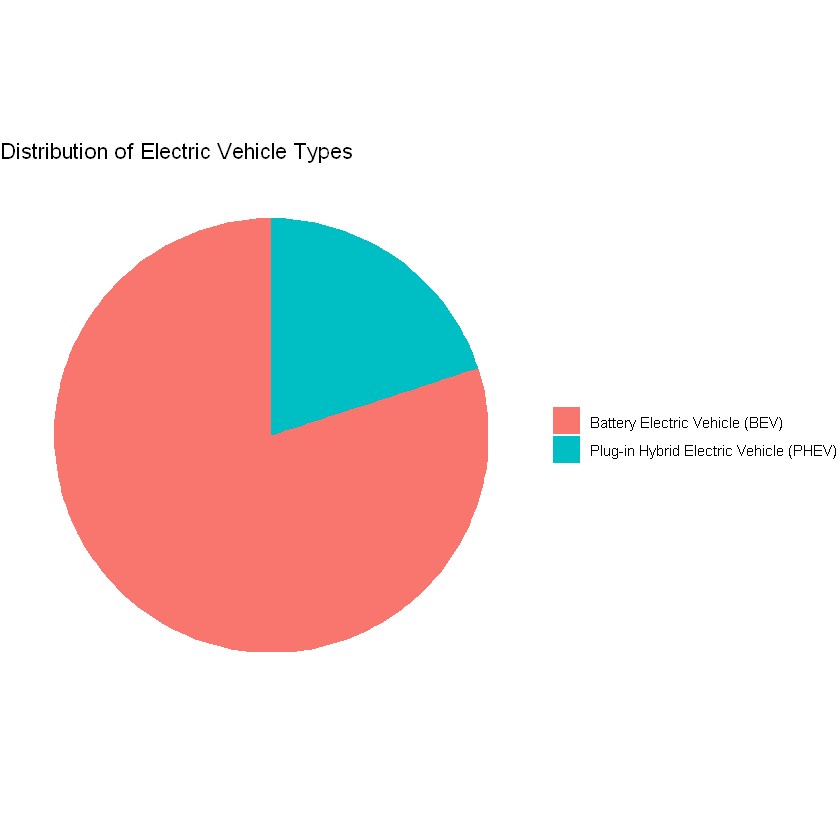

In [5]:
#pie_df = data.frame(df$type, count = table(df$type))
#pie_df

type_counts = table(df$type)
type_counts

ggplot(as.data.frame(type_counts), aes(x = "", y = Freq, fill = Var1)) +
  geom_bar(stat = "identity", width = 1) +
  coord_polar(theta = "y") +
  labs(title = "Distribution of Electric Vehicle Types") +
  theme_void() +
  theme(legend.title = element_blank())

p_bev = type_counts["Battery Electric Vehicle (BEV)"] / sum(type_counts)
p_phev = type_counts["Plug-in Hybrid Electric Vehicle (PHEV)"] / sum(type_counts) 
p_bev
p_phev 

From the chart, we can see that the data is clean and that the proportion of BEV is 0.8 while the proportion of PHEV is 0.2. Now, let's see at the market segmentation by car company.

,Var1,Freq
,<fct>,<int>
41,TESLA,114847
9,CHEVROLET,19261
33,NISSAN,16164
14,FORD,15347
21,KIA,13938
43,TOYOTA,11827
6,BMW,11607
18,HYUNDAI,10357
37,RIVIAN,8863


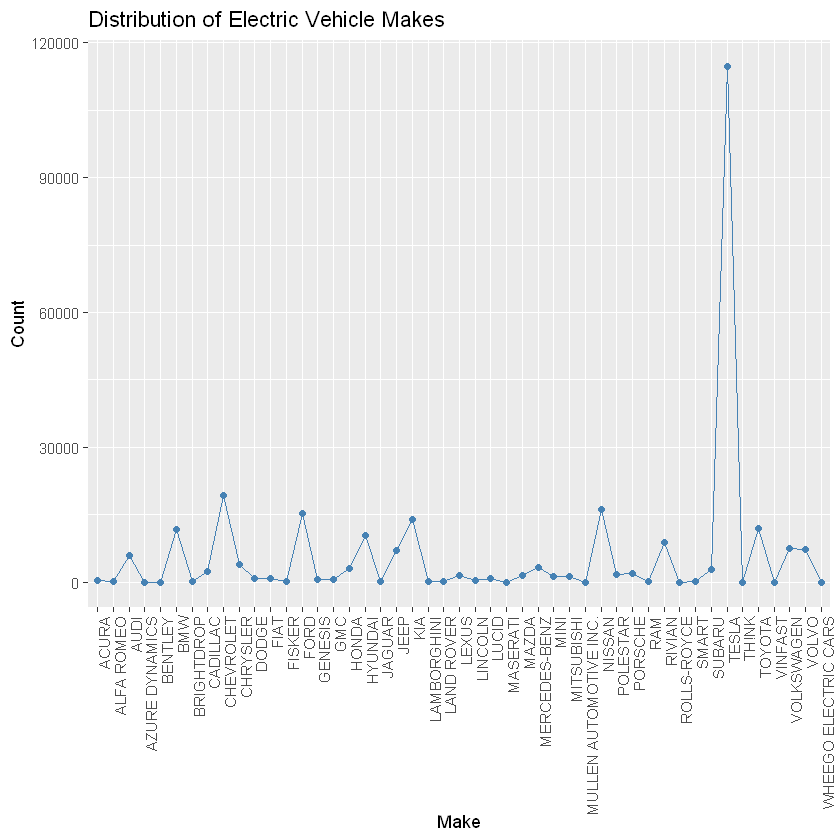

In [6]:
make_counts = as.data.frame(table(df$make))
#make_counts[order(make_counts$Freq, decreasing = TRUE)]
sorted_make_counts = make_counts[order(make_counts$Freq, decreasing = TRUE), ]
sorted_make_counts

ggplot(sorted_make_counts, aes(x = Var1, y = Freq, group = 1)) +
  geom_point(color = "steelblue") +
  geom_line(color = "steelblue") +
  labs(title = "Distribution of Electric Vehicle Makes", x = "Make", y = "Count") +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

Clearly Tesla dominates the market, followed by Chevrolet, Nissan, Ford, KIA and Toyota. Now let's represent the car company segmentation as proportions. I'll leave the top 5 categories and group the rest as **Other**. Then I'll show the count of cars by car company, the percentage and a pie chart representing the proportion.

category,freq
<chr>,<int>
CHEVROLET,19261
FORD,15347
KIA,13938
NISSAN,16164
Other,100223
TESLA,114847


category,value
<fct>,<dbl>
TESLA,41.05
Other,35.82
CHEVROLET,6.88
NISSAN,5.78
FORD,5.49
KIA,4.98


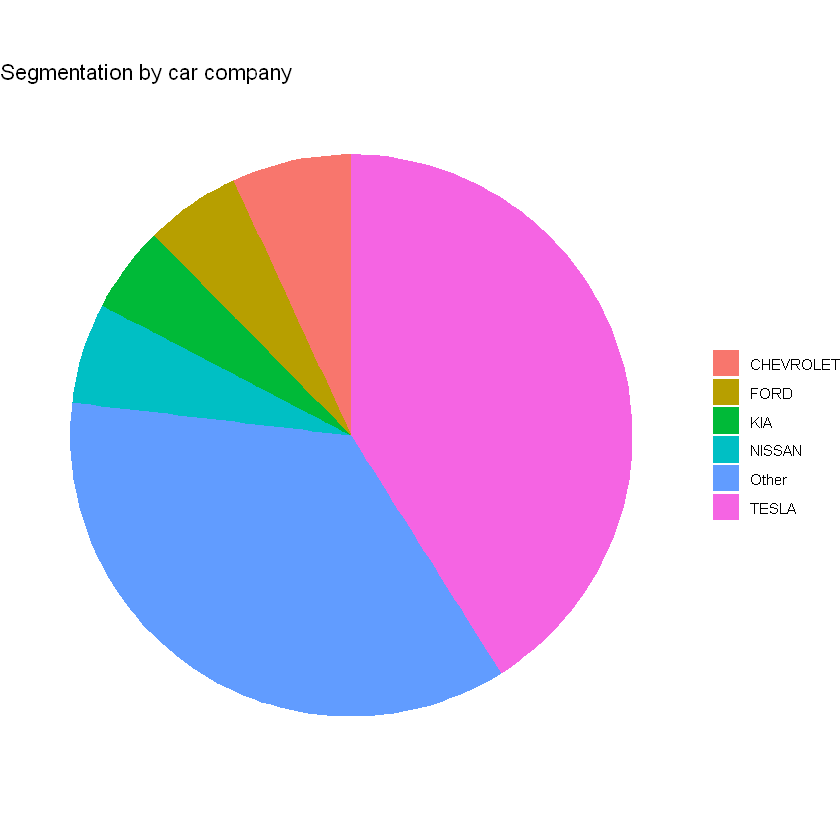

In [7]:
#library(dplyr)
sorted_make_counts = make_counts[order(make_counts$Freq, decreasing = TRUE), ]

df_make_pie <- sorted_make_counts %>%
  mutate(category = as.character(Var1)) %>%
  mutate(category = ifelse(row_number() > 5, "Other", category)) %>%
  group_by(category) %>%
  summarise(freq = sum(Freq), .groups = "drop") 

df_make_pie  

# Market share of top 5 car companies and "Other" category as percentages
total = sum(df_make_pie$freq)
prop = df_make_pie$freq / total
prop = round(prop, 4) * 100

new_df <- data.frame(
  category = df_make_pie[[1]],
  value = prop
)

new_df <- new_df %>%
  arrange(desc(value)) %>%
  mutate(category = factor(category, levels = category))

new_df

ggplot(df_make_pie, aes(x = "", y = freq, fill = category)) +
  geom_bar(stat = "identity", width = 1) + 
  coord_polar(theta = "y") +
  labs(title = "Segmentation by car company") + 
  theme_void() +
  theme(legend.title = element_blank())  

Next, let's analyze which type of cars are eligible for incentives. 
datos
make model clean alternative fuel.... eligibility



                     Clean Alternative Fuel Vehicle Eligible 
                                                       77495 
Eligibility unknown as battery range has not been researched 
                                                      177937 
                       Not eligible due to low battery range 
                                                       24348 

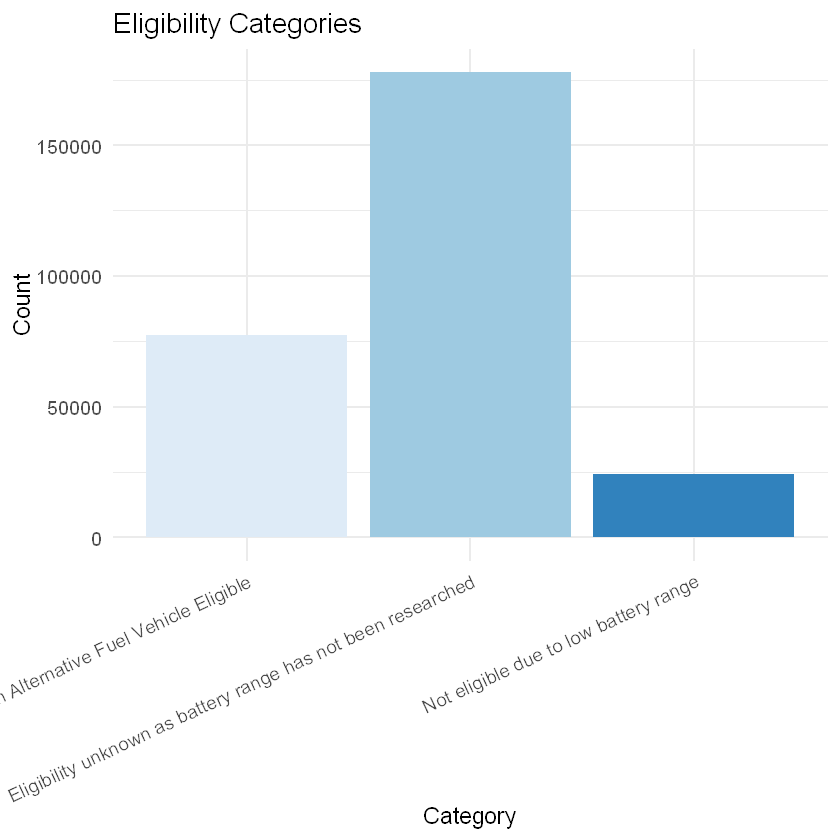

In [8]:
eligible_counts = table(df$eligible_for_incentive)
eligible_counts


# Convert your named vector to a data frame
df_bar <- data.frame(
  category = names(eligible_counts),
  count = as.numeric(eligible_counts)
)

# Bar chart
ggplot(df_bar, aes(x = category, y = count, fill = category)) +
  geom_col() +
  scale_fill_brewer(palette = "Blues") +
  labs(
    title = "Eligibility Categories",
    x = "Category",
    y = "Count"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 25, hjust = 1),
    legend.position = "none"
  )

The bar chart shows that most of the cars are unknown. However, this analysis counts the data starting in 1999. Let's analyze if narrowing the years to 2020-2027 has an impact on the bar chart.

In [9]:
df_2020 = df %>%
  filter(model >= 2020)
head(df_2020)  
dim(df_2020)

,county,city,postal_code,make,model,type,eligible_for_incentive,coords,e_utility
,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,Yakima,Yakima,98903,SUBARU,2023,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,POINT (-120.71847 46.55029),PACIFICORP
2,Kitsap,Poulsbo,98370,BMW,2025,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC
3,Snohomish,Snohomish,98290,JEEP,2024,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,POINT (-122.09305 47.91265),PUGET SOUND ENERGY INC
4,Whitman,Palouse,99161,TESLA,2023,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,POINT (-117.0768 46.91008),AVISTA CORP
5,Kitsap,Kingston,98346,TESLA,2024,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not been researched,POINT (-122.4977 47.79802),PUGET SOUND ENERGY INC
6,Thurston,Lacey,98503,TESLA,2020,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,POINT (-122.82324 47.04437),PUGET SOUND ENERGY INC


[1] 227664      9


                     Clean Alternative Fuel Vehicle Eligible 
                                                       77495 
Eligibility unknown as battery range has not been researched 
                                                      177937 
                       Not eligible due to low battery range 
                                                       24348 

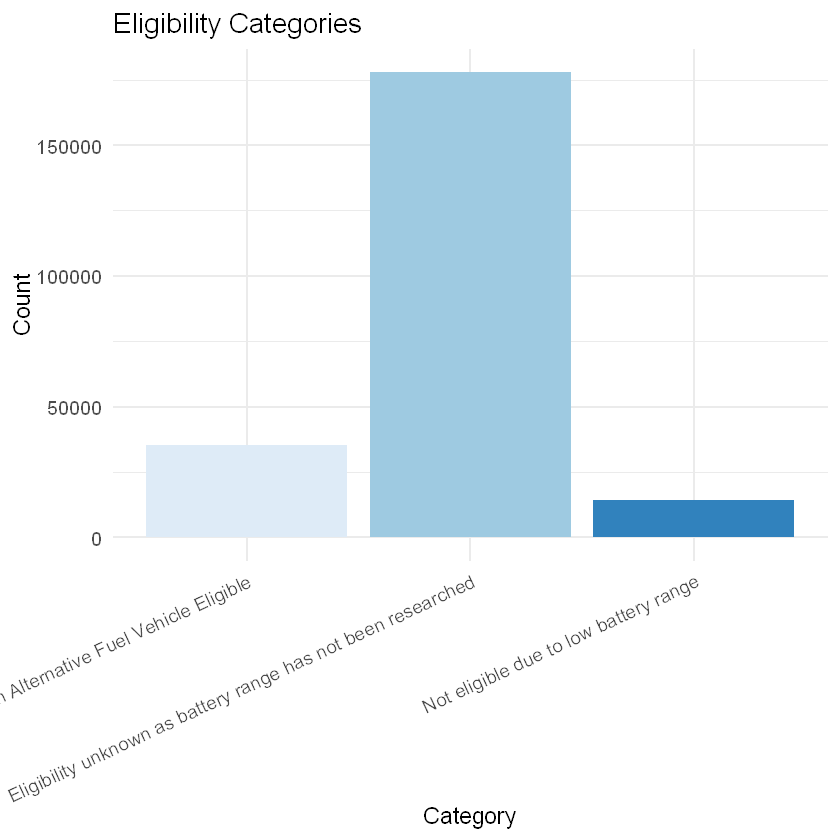

In [10]:
eligible_counts2 = table(df_2020$eligible_for_incentive)
eligible_counts


# Convert your named vector to a data frame
df_bar2 <- data.frame(
  category = names(eligible_counts2),
  count = as.numeric(eligible_counts2)
)

# Bar chart
ggplot(df_bar2, aes(x = category, y = count, fill = category)) +
  geom_col() +
  scale_fill_brewer(palette = "Blues") +
  labs(
    title = "Eligibility Categories",
    x = "Category",
    y = "Count"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 25, hjust = 1),
    legend.position = "none"
  )

The dataframe that comprises years 2020-2027 shows a diminished amount of cars that are eligible or not eligible, however, the amount of cars with unknown status hasn't changed.

Next, I'll calculate the percentages of cars eligible, not eligible and unknown and make a pie graph to see the percentages.




                     Clean Alternative Fuel Vehicle Eligible 
                                                        27.7 
Eligibility unknown as battery range has not been researched 
                                                        63.6 
                       Not eligible due to low battery range 
                                                         8.7 

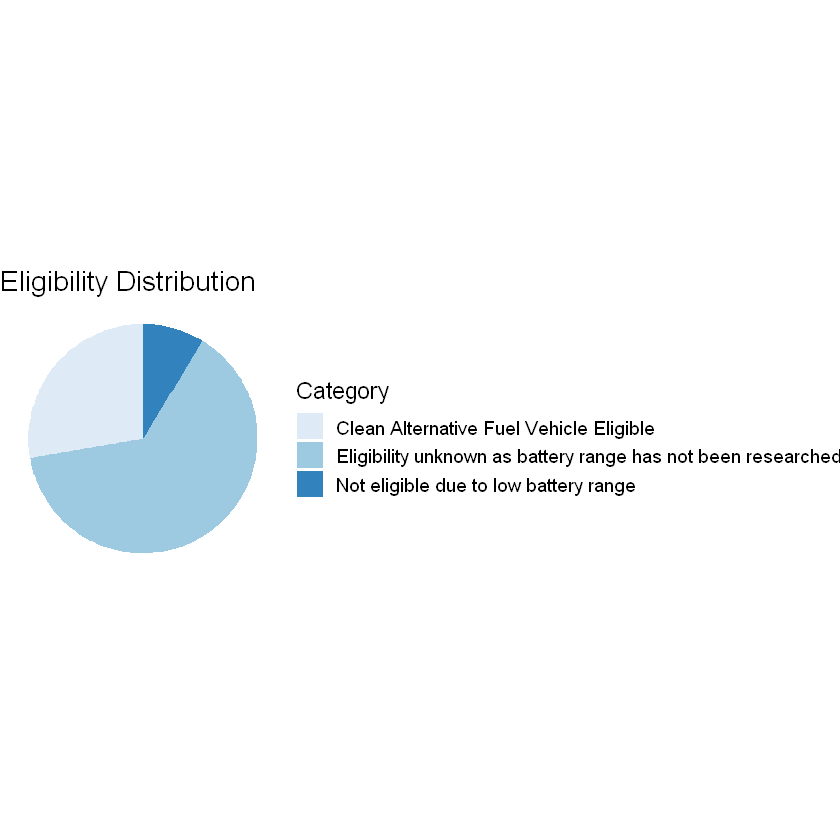

In [11]:
percentages <- round(eligible_counts / sum(eligible_counts) * 100, 2)
percentages
df_eligible <- data.frame(
  category = names(eligible_counts),
  count = as.numeric(eligible_counts)
)

ggplot(df_eligible, aes(x = "", y = count, fill = category)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  scale_fill_brewer(palette = "Blues") +
  labs(
    title = "Eligibility Distribution",
    fill = "Category"
  ) +
  theme_void(base_size = 14)


The next cell shows the percentages for eligible, not eligible and unknown for car models from 2020 and later.


                     Clean Alternative Fuel Vehicle Eligible 
                                                       15.48 
Eligibility unknown as battery range has not been researched 
                                                       78.15 
                       Not eligible due to low battery range 
                                                        6.36 

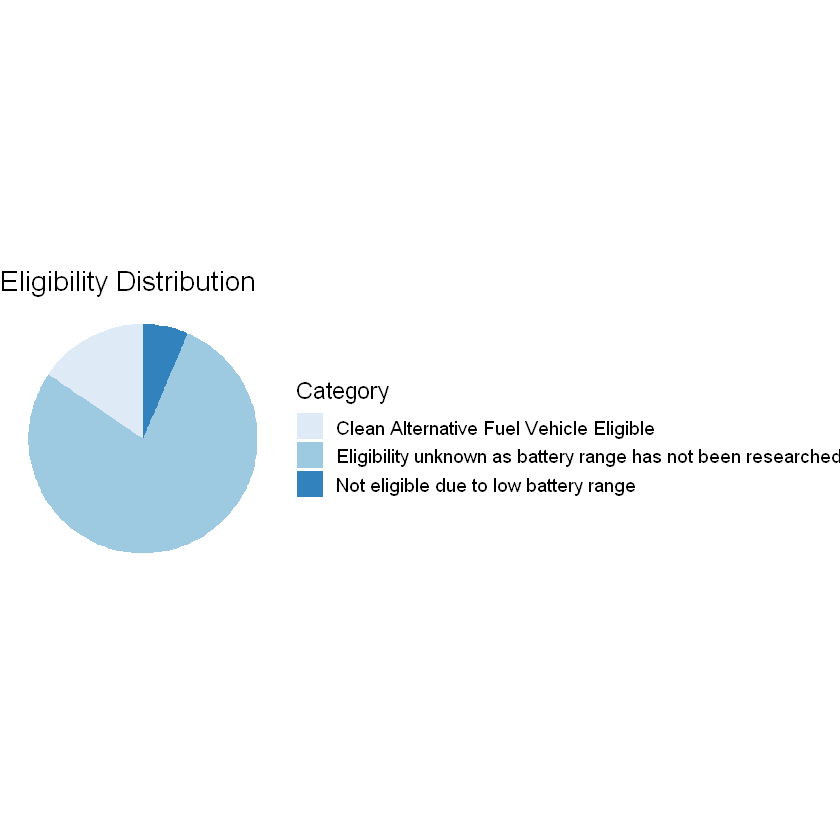

In [12]:
percentages2 <- round(eligible_counts2 / sum(eligible_counts2) * 100, 2)
percentages2
df_eligible <- data.frame(
  category = names(eligible_counts2),
  count = as.numeric(eligible_counts2)
)

ggplot(df_eligible, aes(x = "", y = count, fill = category)) +
  geom_col(width = 1) +
  coord_polar(theta = "y") +
  scale_fill_brewer(palette = "Blues") +
  labs(
    title = "Eligibility Distribution",
    fill = "Category"
  ) +
  theme_void(base_size = 14)

The proportion of eligible and not eligible cars diminished, and most data don't provide insights on whether the cars are eligible as clean alternative fuel vehicles in the Washington area.
